In [1]:
# Dependencies for this project are listed in requirements.txt
# Install with: pip install -r requirements.txt
print("Environment ready.")

Environment ready.


In [2]:
# ==========================================
# REQUIRED LIBRARIES IMPORT
# ==========================================

# Pandas: Main tool for data manipulation and analysis of tabular data
import pandas as pd

# Matplotlib: Base library for creating static and animated charts
import matplotlib.pyplot as plt

# Seaborn: High-level interface for attractive statistical graphics
import seaborn as sns

# Optional configuration for better visualization in the portfolio
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Libraries successfully loaded and environment configured.")

Libraries successfully loaded and environment configured.


In [3]:
# ==========================================
# DATASET LOADING
# ==========================================

# File path definition
file_path = 'amazon.xlsx'

# Load Excel file specifying the raw data sheet
# Note: openpyxl must be installed to read .xlsx files
try:
    df = pd.read_excel(file_path, sheet_name='raw_data')
    print(f"Success: The file '{file_path}' has been loaded.")
except Exception as e:
    print(f"Error loading file: {e}")

# Initial inspection of the first 5 rows
df.head()

Success: The file 'amazon.xlsx' has been loaded.


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,â‚¹399,"â‚¹1,099",0.64,4.2,24269,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,â‚¹199,â‚¹349,0.43,4,43994,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,â‚¹199,"â‚¹1,899",0.90,3.9,7928,ã€ Fast Charger& Data Syncã€‘-With built-in s...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,â‚¹329,â‚¹699,0.53,4.2,94363,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,â‚¹154,â‚¹399,0.61,4.2,16905,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# ==========================================
# TECHNICAL COLUMN INSPECTION
# ==========================================

# info() shows non-null counts and data types
print(df.info())

print("\n")

# describe() provides statistical overview of numeric columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1464 entries, 0 to 1463
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1464 non-null   str    
 1   product_name         1464 non-null   str    
 2   category             1463 non-null   str    
 3   discounted_price     1463 non-null   str    
 4   actual_price         1463 non-null   str    
 5   discount_percentage  1463 non-null   float64
 6   rating               1463 non-null   object 
 7   rating_count         1461 non-null   object 
 8   about_product        1463 non-null   str    
 9   user_id              1127 non-null   str    
 10  user_name            1127 non-null   str    
 11  review_id            1127 non-null   str    
 12  review_title         1127 non-null   str    
 13  review_content       1123 non-null   str    
 14  img_link             1089 non-null   str    
 15  product_link         1089 non-null   str    
 16 

,discount_percentage
count,1463.000000
mean,0.476842
std,0.216445
min,0.000000
25%,0.320000
50%,0.500000
75%,0.630000
max,0.940000


In [5]:
# ==========================================
# PRICE FORMAT CLEANING
# ==========================================

import re # Advanced cleaning using Regular Expressions

def deep_clean_currency(value):
    """Removes any character that is not a digit or a decimal point."""
    if isinstance(value, str):
        # Keeps only numbers (0-9) and the decimal point (.)
        clean_value = re.sub(r'[^\d.]', '', value)
        return clean_value
    return value

# Apply cleaning process
# errors='coerce' will turn any problematic text into NaN to prevent crashes
df['discounted_price'] = df['discounted_price'].apply(deep_clean_currency)
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')

df['actual_price'] = df['actual_price'].apply(deep_clean_currency)
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')

# Drop rows with missing prices to maintain analysis quality
df = df.dropna(subset=['discounted_price', 'actual_price'])

print("Prices sanitized and converted to numeric format.")
df[['discounted_price', 'actual_price']].head()

Prices sanitized and converted to numeric format.


,discounted_price,actual_price
0,399.0,1099.0
1,199.0,349.0
2,199.0,1899.0
3,329.0,699.0
4,154.0,399.0


In [6]:
# ==========================================
# RATING COLUMN CLEANING
# ==========================================

# Convert rating to numeric, handling special characters or empty values
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Count missing values before imputation
missing_count = df['rating'].isna().sum()

# Impute missing values with the mean to preserve records
average_rating = df['rating'].mean()
df['rating'] = df['rating'].fillna(average_rating)

print(f"Missing ratings imputed: {missing_count}")
print(f"Rating column sanitized. Global Average: {average_rating:.2f}")

Missing ratings imputed: 1
Rating column sanitized. Global Average: 4.10


In [7]:
# ==========================================
# BUSINESS METRICS CALCULATION
# ==========================================

# 1. Absolute Price Difference (Customer Savings)
df['discount_amount'] = df['actual_price'] - df['discounted_price']

# 2. Recalculate Discount Percentage for accuracy
df['discount_percentage_real'] = (df['discount_amount'] / df['actual_price']) * 100

# Statistical summary of new metrics
print("Summary of offered discounts:")
print(df[['discount_amount', 'discount_percentage_real']].describe())

Summary of offered discounts:
       discount_amount  discount_percentage_real
count      1463.000000               1463.000000
mean       2319.861141                 47.677464
std        4607.145456                 21.644695
min           0.000000                  0.000000
25%         370.500000                 31.969390
50%         800.000000                 50.016672
75%        1951.500000                 62.880411
max       61910.000000                 94.118824


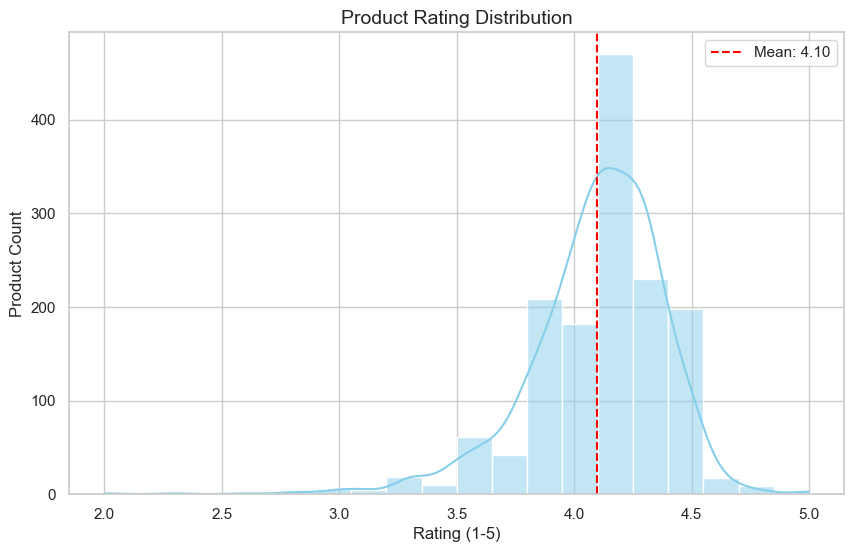

In [8]:
# ==========================================
# VISUALIZATION: RATING DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 6))

# Create histogram with Kernel Density Estimate (KDE)
sns.histplot(df['rating'], bins=20, kde=True, color='skyblue')

# Add vertical line for the mean
plt.axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["rating"].mean():.2f}')

plt.title('Product Rating Distribution', fontsize=14)
plt.xlabel('Rating (1-5)', fontsize=12)
plt.ylabel('Product Count', fontsize=12)
plt.legend()
plt.show()

C:\Users\gusta\AppData\Local\Temp\ipykernel_33708\3077455848.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='tab10')


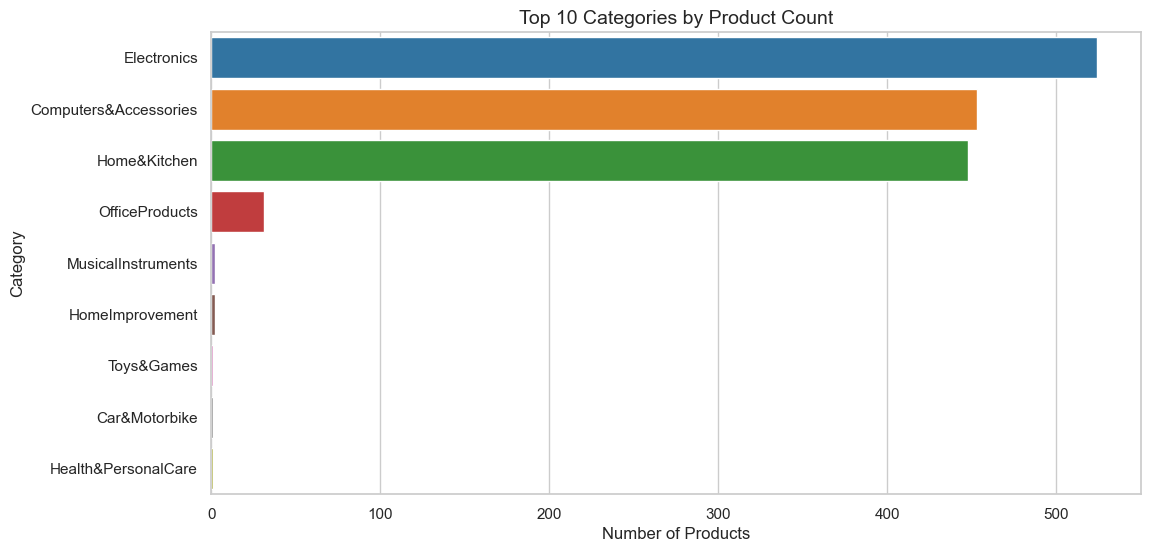

In [9]:
# ==========================================
# MAIN CATEGORY ANALYSIS
# ==========================================

# Extract the primary category (before the first '|')
df['main_category'] = df['category'].str.split('|').str[0]

# Count product frequency per main category
top_categories = df['main_category'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='tab10')

plt.title('Top 10 Categories by Product Count', fontsize=14)
plt.xlabel('Number of Products', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.show()

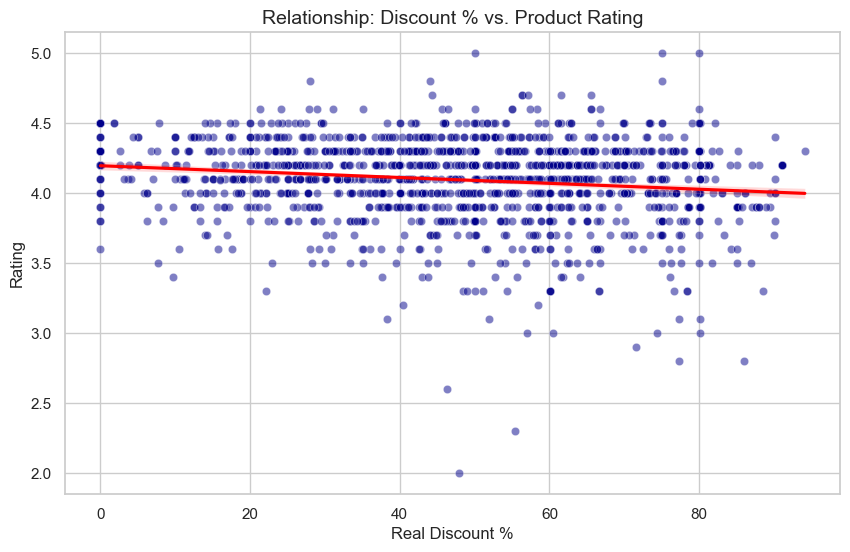

Pearson Correlation Coefficient: -0.1556


In [10]:
# ==========================================
# CORRELATION: DISCOUNT VS. RATING
# ==========================================

plt.figure(figsize=(10, 6))

# Scatter plot to visualize the relationship
sns.scatterplot(data=df, x='discount_percentage_real', y='rating', alpha=0.5, color='darkblue')

# Regression line to show the trend
sns.regplot(data=df, x='discount_percentage_real', y='rating', scatter=False, color='red')

plt.title('Relationship: Discount % vs. Product Rating', fontsize=14)
plt.xlabel('Real Discount %', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

# Pearson Correlation Coefficient calculation
correlation = df['discount_percentage_real'].corr(df['rating'])
print(f"Pearson Correlation Coefficient: {correlation:.4f}")

In [11]:
# ==========================================
# STAR PRODUCTS (TOP VALUE)
# ==========================================

# Filter high-rated products with significant discounts
star_products = df[(df['rating'] >= 4.5) & (df['discount_percentage_real'] >= 50)]

# Select relevant columns and show top 5
top_5_value = star_products[['product_name', 'main_category', 'rating', 'discount_percentage_real']].sort_values(by='rating', ascending=False).head(5)

print("Top 5 Recommended Products (High Rating + High Discount):")
top_5_value

Top 5 Recommended Products (High Rating + High Discount):


,product_name,main_category,rating,discount_percentage_real
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",Computers&Accessories,5.0,75.075075
174,Syncwire LTG to USB Cable for Fast Charging Co...,Computers&Accessories,5.0,80.040020
774,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,Computers&Accessories,5.0,50.100000
1298,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",Home&Kitchen,4.8,75.086039
459,Spigen EZ Fit Tempered Glass Screen Protector ...,Electronics,4.7,65.539841


In [12]:
# ==========================================
# PROCESSED DATA EXPORT
# ==========================================

# Save the cleaned dataframe to a new CSV file for the repository
df.to_csv('amazon_sales_cleaned.csv', index=False)

print("File 'amazon_sales_cleaned.csv' generated for repository.")

File 'amazon_sales_cleaned.csv' generated for repository.


## Key Insights

1. **Tech Dominance:** Electronics and Computers & Accessories concentrate the highest product volume and sales activity.
2. **Aggressive Discounting:** Average discount is **47.6%**, reaching up to **94%** in extreme cases — highly competitive, price-driven market.
3. **Quality vs. Price:** Pearson correlation between discount % and rating is near **0** — higher discounts do not guarantee better customer satisfaction.
4. **Overall Satisfaction:** Average rating of **4.10/5.0** reflects a healthy quality standard across the catalog.